In [1]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns
import chardet
import datetime

In [2]:
with open("data.csv", 'rb') as f:
    result = chardet.detect(f.read(10))
result

{'encoding': 'ascii',
 'confidence': 1.0,
 'language': 'fr',
 'mime_type': 'text/plain'}

In [3]:
df= pd.read_csv("data.csv", encoding='latin')

# STEP 1 - Data Understanding

In [4]:
# How many rows are there?
df_shape= df.shape
print(df_shape[0])


541909


In [5]:
# How many columns?
print(df_shape[1])

8


In [6]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [7]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [8]:
# How many unique orders?

df['InvoiceNo'].nunique()

25900

In [9]:
# How many products?
'''
    StockCode is a code/identifier used to identify a particular product in the transaction dataset.
'''
df['StockCode'].nunique()

4070

In [10]:
# How many countries ?

df['Country'].nunique() 
print(
    "There are 38 countries."
)

There are 38 countries.


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [12]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


# STEP 2 — Data cleaning

## Missing-value analysis 

In [13]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [14]:
# Which columns have missing values? 

'''
    "Description" and "CustomerID" have missing values.

'''

'\n    "Description" and "CustomerID" have missing values.\n\n'

In [15]:
# What percentage is missing? 



print("The missing percentage for description column :    ",df['Description'].isnull().mean() * 100) 

print("The missing percentage for customerID column :    ",df['CustomerID'].isnull().mean() * 100) 


The missing percentage for description column :     0.2683107311375157
The missing percentage for customerID column :     24.926694334288598


In [16]:
''' 
    The perncetage of missing value is 0.268%
    The percentage of missing value for customerID column is 24.9266%
'''

' \n    The perncetage of missing value is 0.268%\n    The percentage of missing value for customerID column is 24.9266%\n'

In [17]:
# Should you remove the rows?  Should you replace missing values? Why ?

sales_df = df.copy()
customer_df = df.dropna(subset=["CustomerID"])

In [18]:
customer_df.shape

(406829, 8)

In [19]:
customer_df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [20]:
sales_df.shape

(541909, 8)

In [21]:
sales_df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

## Duplicate analysis

In [22]:
df.duplicated().sum()

np.int64(5268)

In [23]:
sales_df = sales_df.drop_duplicates()


In [24]:
customer_df.duplicated().sum()

np.int64(5225)

In [25]:
df= df.drop_duplicates()

In [26]:
print(sales_df.duplicated().sum())
print(df.duplicated().sum())


0
0


In [27]:
df['CustomerID'].duplicated().sum()

np.int64(532268)

In [28]:
df['InvoiceNo'].duplicated().sum()

np.int64(510741)

In [29]:
print(df['Description'].duplicated().sum())
print(df['Description'].nunique())

532417
4223


## Data-type validation

In [30]:
if df['CustomerID'].dtype == int:
    print("True")
else:
    print("False")   

False


In [31]:
if df['InvoiceNo'].dtype != int:
    print("False")
else:
    print("True")

False


In [32]:
if df['InvoiceDate'].dtype == 'datetime64(ns)':
    print("True")
else:
    print("False")


False


## Outlier detection


### Extremly expensive products

In [33]:
print("The most expensive product price is :",max(df['UnitPrice']))
df['UnitPrice'].sort_values(ascending=False).head(10)


The most expensive product price is : 38970.0


222681    38970.00
524602    17836.46
43702     16888.02
43703     16453.71
16356     13541.33
15016     13541.33
15017     13541.33
16232     13474.79
524601    11586.50
299982    11062.06
Name: UnitPrice, dtype: float64

In [34]:
df[df['UnitPrice']<0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,8/12/2011 14:51,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,8/12/2011 14:52,-11062.06,NaN,United Kingdom


In [35]:
df[df['UnitPrice']==0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,12/1/2010 14:32,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,12/1/2010 14:34,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
536981,581234,72817,NaN,27,12/8/2011 10:33,0.0,NaN,United Kingdom
538504,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,12/8/2011 13:58,0.0,NaN,United Kingdom
538505,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,12/8/2011 13:58,0.0,NaN,United Kingdom
538554,581408,85175,NaN,20,12/8/2011 14:06,0.0,NaN,United Kingdom


### Extremely large quantities

In [36]:

print("The large quantity is : ",max(df['Quantity']))

The large quantity is :  80995


In [37]:
normal_price_sales = df[df['UnitPrice']>0]
print(normal_price_sales.shape)

zero_price_sales= df[df['UnitPrice']==0]
print(zero_price_sales.shape)

negative_price_sales = df[df['UnitPrice']<0]
print(negative_price_sales.shape)

(534129, 8)
(2510, 8)
(2, 8)


In [38]:
''' 
Online Retail type dataset, a zero unit price (UnitPrice = 0) can represent things like:
 Free items / promotional items
 Samples
 Data adjustments
 Incorrectly recorded transactions
'''

' \nOnline Retail type dataset, a zero unit price (UnitPrice = 0) can represent things like:\n Free items / promotional items\n Samples\n Data adjustments\n Incorrectly recorded transactions\n'

In [39]:
negative_quantity = df[df['Quantity']<0 ]
negative_quantity.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom


In [40]:
negative_quantity['InvoiceNo'].str.startswith("C").value_counts()

InvoiceNo
True     9251
False    1336
Name: count, dtype: int64

In [41]:
# Differenciat cancel transaction from normal transaction

cancel_transaction_df = df[df['InvoiceNo'].str.startswith('C')]

In [42]:
cancel_transaction_df.shape

(9251, 8)

In [43]:
# Normal transaction 
normal_transacton_df = df[~df['InvoiceNo'].str.startswith('C')]

In [44]:
df['TransactionType'] = 'Sale'

df.loc[df['Quantity'] < 0, 'TransactionType'] = 'Return/Adjustment'

df.loc[
    df['InvoiceNo'].astype(str).str.startswith('C'),
    'TransactionType'
] = 'Cancellation'

In [45]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TransactionType
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,Sale
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,Sale
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,Sale
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,Sale
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,Sale


In [46]:
df.shape

(536641, 9)

In [47]:
df.loc[
    df['InvoiceNo'].astype(str).str.startswith('A'),
    'TransactionType'
] = 'Bad Debt Adjustment'

In [48]:
df.shape

(536641, 9)

# STEP 3 — Build important business KPIs

## Sales KPIs

In [49]:
# KPI - Key Performance Indicator.




df['Revenue']=df['UnitPrice']*df['Quantity']
sales = df[(~df['InvoiceNo'].str.startswith('C')) &
           (~df['InvoiceNo'].str.startswith('A')) &
           (df['Quantity']>0) &
           (df['UnitPrice']>0)]

gross_sales = sales['Revenue'].sum()
print("The ** Grosss Revenue**      :",gross_sales)

The ** Grosss Revenue**      : 10631048.743999999


In [50]:
cancel_transaction_df['Revenue']= cancel_transaction_df['Quantity']*cancel_transaction_df['UnitPrice']
cancellation_value = cancel_transaction_df['Revenue'].sum()

print("The  **Cancellation Value**    :", abs(cancellation_value))

The  **Cancellation Value**    : 893979.73


In [51]:
other_negative_qty = df[
    (df['Quantity'] < 0) &
    (~df['InvoiceNo'].astype(str).str.startswith('C')) &
    (~df['InvoiceNo'].astype(str).str.startswith('A'))
]

other_negative_qty['Revenue'] = (
    other_negative_qty['Quantity'] *
    other_negative_qty['UnitPrice']
)

other_adjustment_value = abs(
    other_negative_qty['Revenue'].sum()
)
print("The other adjustment value is :",other_adjustment_value)

The other adjustment value is : 0.0


In [52]:
# Net Revenue

net_revenue = gross_sales-abs(cancellation_value)
print("The **net revenue**    :",net_revenue)

The **net revenue**    : 9737069.013999999


In [53]:
# Units Sold means Number of unit sold

sum(normal_price_sales['Quantity'])

5296860

In [54]:
# Average Order Value

total_complete_order = normal_transacton_df['InvoiceNo'].nunique()
aov= net_revenue / total_complete_order
print("The Average Order Value        :    ",round(aov,2))

The Average Order Value        :     441.31


In [55]:
# Average Selling Price (ASP)


units_sold = normal_price_sales['Quantity'].sum()
asp = gross_sales / units_sold

print("The Average Selling Price  :  ",round(asp,2))

The Average Selling Price  :   2.01


## Customer KPIs

In [56]:
# Total Customer 

total_customer = customer_df['CustomerID'].nunique()
print("Total unique Customers : ",total_customer)

Total unique Customers :  4372


In [57]:
#Orders per Customer

total_complete_order
orders_per_customer = total_complete_order / total_customer

print("Orders per Customer:", round(orders_per_customer,2))

Orders per Customer: 5.05


In [58]:
# Revenue per Customer

revenue_per_customer = net_revenue / total_customer

print("Revenue per Customer:", round(revenue_per_customer,2))

Revenue per Customer: 2227.14


# STEP 4 - Time-series analysis

In [59]:
sales['InvoiceDate'] = pd.to_datetime(sales['InvoiceDate'])

In [60]:
print(min(sales['InvoiceDate']))
print(max(sales["InvoiceDate"]))

2010-12-01 08:26:00
2011-12-09 12:50:00


In [61]:

sales['Year']=sales['InvoiceDate'].dt.year

In [62]:
sales['Month']=sales['InvoiceDate'].dt.month

In [63]:
sales['Day']=sales["InvoiceDate"].dt.day_name()

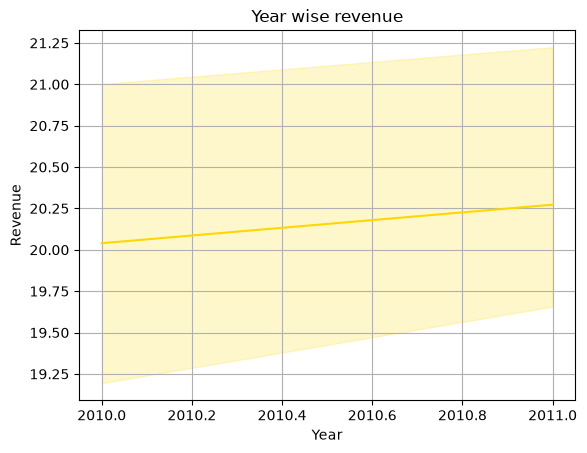

In [64]:
sns.lineplot(x= sales['Year'],y=sales['Revenue'],color='gold')
plt.grid()
plt.title("Year wise revenue" )
plt.show()

In [65]:
# Orders by Year

order_by_year = sales.groupby('Year')['InvoiceNo'].count()

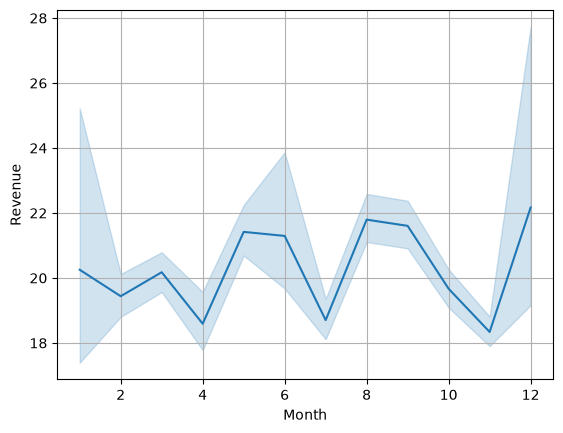

In [66]:
sns.lineplot(x= sales['Month'],y=sales['Revenue'])
plt.grid()
plt.show()

In [67]:
# Orders by Month
order_by_month = sales.groupby('Month')['InvoiceNo'].count()

/tmp/ipykernel_6527/3866968481.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=order_by_month.index,y=order_by_month.values,palette= 'plasma',zorder=2)


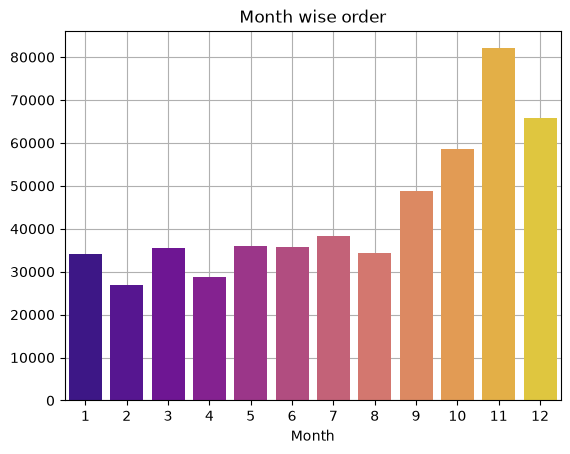

In [68]:
sns.barplot(x=order_by_month.index,y=order_by_month.values,palette= 'plasma',zorder=2)
plt.title("Month wise order")
plt.grid()
plt.show()

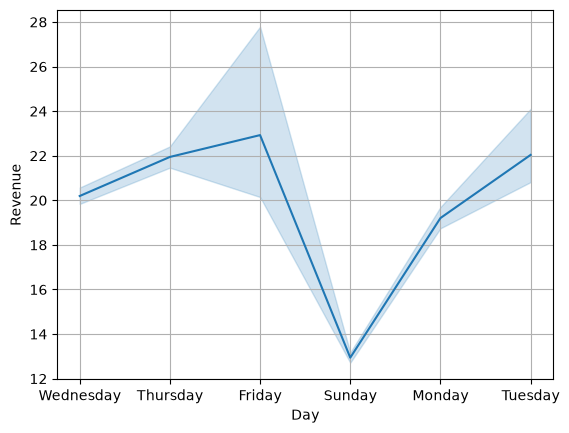

In [69]:
sns.lineplot(x= sales['Day'],y=sales['Revenue'])
plt.grid()
plt.show()

In [70]:
# Order of Day in a week
order_by_day=sales.groupby('Day')['InvoiceNo'].count()

/tmp/ipykernel_6527/956198441.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=order_by_day.index, y=order_by_day.values, palette='viridis')


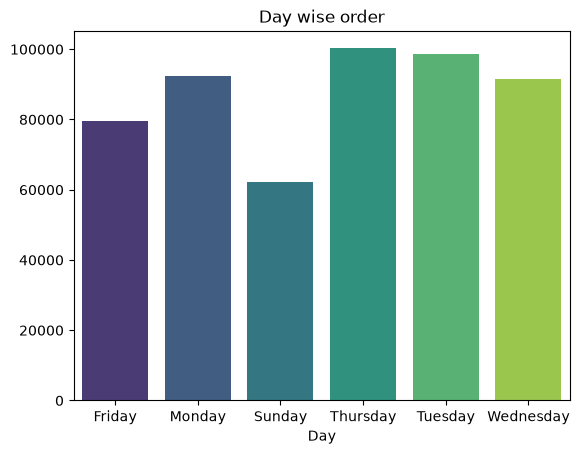

In [71]:
sns.barplot(x=order_by_day.index, y=order_by_day.values, palette='viridis')
plt.title("Day wise order")
plt.show()

# STEP 5 — Product analysis

In [73]:
''' Top products by
        Revenue
        Quantity sold
        Number of orders
        
    Bottom products
        Lowest revenue
        Lowest quantity
        Highest return rate
        '''



' Top products by\n        Revenue\n        Quantity sold\n        Number of orders\n\n    Bottom products\n        Lowest revenue\n        Lowest quantity\n        Highest return rate\n        '

In [74]:
top_ten_product_by_revenue = sales.groupby('StockCode')['Revenue'].sum().sort_values(ascending = False).head(10)
top_ten_product_by_revenue

StockCode
DOT       206248.77
22423     174156.54
23843     168469.60
85123A    104462.75
47566      99445.23
85099B     94159.81
23166      81700.92
POST       78101.88
M          77750.27
23084      66870.03
Name: Revenue, dtype: float64

In [75]:
bottom_ten_product_by_revenue = sales.groupby('StockCode')['Revenue'].sum().sort_values(ascending = True).head(10)
bottom_ten_product_by_revenue

StockCode
PADS      0.003
84227     0.420
51014c    0.830
21268     0.840
90084     0.850
84206B    0.950
84201C    0.950
84990     1.100
21009     1.250
35597A    1.250
Name: Revenue, dtype: float64

In [76]:
# 2
top_ten_product_by_quantity_sold = sales.groupby('StockCode')['Quantity'].sum().sort_values(ascending = False).head(10)
top_ten_product_by_quantity_sold

StockCode
23843     80995
23166     78033
22197     56898
84077     54951
85099B    48371
85123A    37641
21212     36396
84879     36362
23084     30739
22492     26633
Name: Quantity, dtype: int64

In [77]:
bottom_ten_product_by_quantity_sold = sales.groupby('StockCode')['Quantity'].sum().sort_values(ascending = True).head(10)
bottom_ten_product_by_quantity_sold

StockCode
DCGS0070    1
23643       1
90152C      1
23609       1
85035b      1
85031B      1
85036b      1
85035c      1
90135A      1
85034b      1
Name: Quantity, dtype: int64

In [78]:
# 3. 
top_ten_product_by_number_of_order = sales.groupby('StockCode')['InvoiceNo'].count().sort_values(ascending = False).head(10)
top_ten_product_by_number_of_order 

StockCode
85123A    2253
85099B    2109
22423     2007
47566     1699
20725     1582
84879     1476
22197     1418
22720     1392
21212     1352
22383     1306
Name: InvoiceNo, dtype: int64

In [79]:
bottom_ten_product_by_number_of_order = sales.groupby('StockCode')['InvoiceNo'].count().sort_values(ascending = True).head(10)
bottom_ten_product_by_number_of_order

StockCode
84620       1
82613a      1
17001       1
90214U      1
85035c      1
85035b      1
84596g      1
17028J      1
23449       1
DCGS0070    1
Name: InvoiceNo, dtype: int64